# K-Nearest Neighbors (KNN)
K-Nearest Neighbors (KNN) is een eenvoudig en intuïtief machine learning-algoritme dat wordt gebruikt voor zowel classificatie- als regressietaken. Het principe achter KNN is gebaseerd op het idee dat vergelijkbare gegevenspunten zich in de buurt van elkaar bevinden in de feature-ruimte. Bij het classificeren van een nieuw gegevenspunt kijkt KNN naar de 'k' dichtstbijzijnde buren (gegevenspunten) in de trainingsset en wijst het nieuwe punt toe aan de klasse die het meest voorkomt onder deze buren.

In [1]:
import sys
import os
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import numpy as np
import time
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

# Add the parent directory (project root) to Python path
project_root = os.path.abspath('..')  # Go up one level from current notebook
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from utils.libs_generic_functions import LibsDataLoader, LibsDataPreprocessor
from utils.baseline_correction_functions import BaselineCorrector, analyze_correction_quality, print_quality_report
from utils.normalization_functions import Normalizer
from utils.pca_analysis_functions import PCAAnalyzer, quick_pca_analysis
from utils.lda_analysis_functions import quick_lda_analysis
from utils.measure_model_details import calculate_lda_knn_memory_usage

Libraries imported successfully!


Voordat we KNN goed kunnen gebruiken moeten wij dimensionaliteitsreductie toepassen. Dit is omdat KNN veel moeite heeft met "The curse of dimensionality", oftewel dimensionaliteitsvloek. De data bestaat namelijk uit een set van (51453, 8188). KNN zal hier niet goed kunnen classificeren. 

Hierbij zullen wij LDA en PCA testen

In [2]:
%%time
df = pd.read_csv("../data/csv/processed_data.csv")

CPU times: total: 1min 4s
Wall time: 1min 4s


In [3]:
%%time
Preprocessor = LibsDataPreprocessor()
X_train, X_test, y_train, y_test, label_encoder, wavelength_columns = Preprocessor.prepare_ml_data(df)

PREPARING DATA FOR MACHINE LEARNING
Original dataset shape: (51453, 8004)
Target distribution:
origin
tread         17936
innerliner    17260
sidewall      16257
Name: count, dtype: int64

Splitting complete dataset (test_size=0.2, random_state=42)...
Training dataset shape: (41162, 8004)
Test dataset shape: (10291, 8004)
Training target distribution:
origin
tread         14349
innerliner    13808
sidewall      13005
Name: count, dtype: int64
Test target distribution:
origin
tread         3587
innerliner    3452
sidewall      3252
Name: count, dtype: int64

Identified 8001 wavelength columns
Extracting features and targets from training set...
Extracting features and targets from test set...
Converting features to numeric...
Encoding labels...

Final results:
Training features shape: (41162, 8001)
Test features shape: (10291, 8001)
Label classes: ['innerliner' 'sidewall' 'tread']
Training label distribution: [13808 13005 14349]
Test label distribution: [3452 3252 3587]
CPU times: total

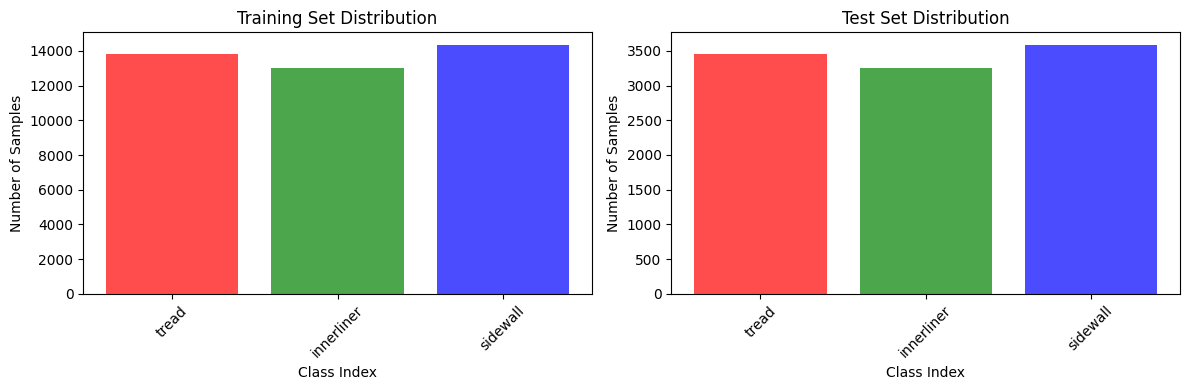

CPU times: total: 266 ms
Wall time: 324 ms


In [24]:
%%time


# Display train/test distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Training set distribution
train_unique, train_counts = np.unique(y_train, return_counts=True)
ax1.bar(range(len(train_unique)), train_counts, alpha=0.7, color=['red', 'green', 'blue'])
ax1.set_title('Training Set Distribution')
ax1.set_xlabel('Class Index')
ax1.set_ylabel('Number of Samples')
ax1.set_xticks(range(len(train_unique)))
ax1.set_xticklabels(("tread", "innerliner", "sidewall"), rotation=45)

# Test set distribution  
test_unique, test_counts = np.unique(y_test, return_counts=True)
ax2.bar(range(len(test_unique)), test_counts, alpha=0.7, color=['red', 'green', 'blue'])
ax2.set_title('Test Set Distribution')
ax2.set_xlabel('Class Index')
ax2.set_ylabel('Number of Samples')
ax2.set_xticks(range(len(test_unique)))
ax2.set_xticklabels(("tread", "innerliner", "sidewall"), rotation=45)

plt.tight_layout()
plt.show()

In [5]:
# Filter dataset to NIST top 50% wavelengths for KNN analysis
print("=" * 70)
print("PREPARING NIST FILTERED DATASET FOR KNN ANALYSIS")
print("=" * 70)

# Load NIST top 50% wavelengths
nist_top_50_percent_df = pd.read_csv('../data/csv/nist_top_50_percent_wavelengths.csv')

# Extract all unique wavelengths from nist_top_50_percent_df
nist_wavelengths_set = set()
for column in nist_top_50_percent_df.columns:
    element_wavelengths = nist_top_50_percent_df[column].dropna().tolist()
    nist_wavelengths_set.update([float(wl) for wl in element_wavelengths if pd.notna(wl)])

# Get wavelength columns from df (exclude metadata columns)
metadata_columns = ['tire_number', 'origin', 'measurement_id']
all_wavelength_columns = [col for col in df.columns if col not in metadata_columns]

# Find wavelengths to keep (with tolerance for matching)
tolerance = 0.1  # 0.1 nm tolerance
wavelengths_to_keep = []

for col in all_wavelength_columns:
    col_wl = float(col)
    for nist_wl in nist_wavelengths_set:
        if abs(col_wl - nist_wl) <= tolerance:
            wavelengths_to_keep.append(col)
            break

# Create filtered dataframe
columns_to_keep = metadata_columns + wavelengths_to_keep
nist_filtered_df = df[columns_to_keep].copy()

print(f"NIST filtered dataset created:")
print(f"   Original wavelengths: {len(all_wavelength_columns)}")
print(f"   NIST wavelengths kept: {len(wavelengths_to_keep)}")
print(f"   Reduction: {((len(all_wavelength_columns) - len(wavelengths_to_keep)) / len(all_wavelength_columns)) * 100:.1f}%")

# Prepare NIST filtered data
nist_X_train, nist_X_test, nist_y_train, nist_y_test, nist_label_encoder, nist_wavelength_columns = Preprocessor.prepare_ml_data(nist_filtered_df)

# Normalize NIST filtered data
normalizer = Normalizer()
nist_X_train_scaled = normalizer.apply_standard_normal_variate_on_dataset(nist_X_train)
nist_X_test_scaled = normalizer.apply_standard_normal_variate_on_dataset(nist_X_test)

print(f"NIST filtered data prepared:")
print(f"   Training shape: {nist_X_train_scaled.shape}")
print(f"   Test shape: {nist_X_test_scaled.shape}")

PREPARING NIST FILTERED DATASET FOR KNN ANALYSIS
NIST filtered dataset created:
   Original wavelengths: 8001
   NIST wavelengths kept: 377
   Reduction: 95.3%
PREPARING DATA FOR MACHINE LEARNING
Original dataset shape: (51453, 380)
Target distribution:
origin
tread         17936
innerliner    17260
sidewall      16257
Name: count, dtype: int64

Splitting complete dataset (test_size=0.2, random_state=42)...
Training dataset shape: (41162, 380)
Test dataset shape: (10291, 380)
Training target distribution:
origin
tread         14349
innerliner    13808
sidewall      13005
Name: count, dtype: int64
Test target distribution:
origin
tread         3587
innerliner    3452
sidewall      3252
Name: count, dtype: int64
NIST filtered dataset created:
   Original wavelengths: 8001
   NIST wavelengths kept: 377
   Reduction: 95.3%
PREPARING DATA FOR MACHINE LEARNING
Original dataset shape: (51453, 380)
Target distribution:
origin
tread         17936
innerliner    17260
sidewall      16257
Name: co

In [5]:
# Create Information Gain subset (similar wavelength ranges as before)
print("=" * 70)
print("CREATING INFORMATION GAIN WAVELENGTH SUBSET FOR KNN")
print("=" * 70)

# Define Information Gain wavelength ranges (from previous analysis)
ig_wavelength_ranges = [(670, 750), (950, 960)]

# Convert column names to wavelengths and filter
wavelength_values = [float(col) for col in X_train.columns]
selected_indices = []
selected_wavelengths = []

for i, wl in enumerate(wavelength_values):
    for start_wl, end_wl in ig_wavelength_ranges:
        if start_wl <= wl <= end_wl:
            selected_indices.append(i)
            selected_wavelengths.append(wl)
            break

# Create filtered datasets
ig_X_train_scaled = X_train.iloc[:, selected_indices]
ig_X_test_scaled = X_test.iloc[:, selected_indices]

print(f"Information Gain subset created:")
print(f"   Selected wavelengths: {len(selected_wavelengths)}")
print(f"   Training shape: {ig_X_train_scaled.shape}")
print(f"   Test shape: {ig_X_test_scaled.shape}")
print(f"   Wavelength ranges: {ig_wavelength_ranges}")

CREATING INFORMATION GAIN WAVELENGTH SUBSET FOR KNN
Information Gain subset created:
   Selected wavelengths: 902
   Training shape: (41162, 902)
   Test shape: (10291, 902)
   Wavelength ranges: [(670, 750), (950, 960)]


In [ ]:
# Import additional libraries for comprehensive testing
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
import time
import tracemalloc
import gc
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Add the measure_model_details import
from utils.measure_model_details import (
    measure_training_time, measure_inference_time, get_memory_usage,
)

def comprehensive_knn_evaluation():
    """
    Comprehensive KNN evaluation across 4 different feature sets:
    1. PCA reduced features
    2. LDA reduced features  
    3. Information Gain selected wavelengths
    4. NIST emission line selected features
    """
    
    print("=" * 80)
    print("COMPREHENSIVE KNN EVALUATION")
    print("=" * 80)
    
    # Initialize results storage
    evaluation_results = {}
    
    # Common hyperparameter grid for all tests
    param_grid = {
        'n_neighbors': [1, 3, 5, 7, 9, 11, 15, 19, 25],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan', 'minkowski'],
        'p': [1, 2]  # For minkowski metric
    }
    
    print(f"Parameter grid size: {len(param_grid['n_neighbors']) * len(param_grid['weights']) * len(param_grid['metric']) * len(param_grid['p'])} combinations")
    print(f"Cross-validation folds: 3")
    print()
    
    return param_grid, evaluation_results

def evaluate_knn_configuration(X_train, X_test, y_train, y_test, 
                              config_name, param_grid, label_encoder,
                              n_runs=3):
    """
    Evaluate a single KNN configuration with comprehensive metrics.
    
    Parameters:
    -----------
    X_train, X_test : array-like
        Training and test features
    y_train, y_test : array-like
        Training and test labels
    config_name : str
        Name of the configuration being tested
    param_grid : dict
        Hyperparameter grid for GridSearchCV
    label_encoder : LabelEncoder
        Label encoder for classification reports
    n_runs : int, default=3
        Number of runs for timing measurements
        
    Returns:
    --------
    dict : Comprehensive evaluation results
    """
    
    print(f"\n{'='*60}")
    print(f"EVALUATING: {config_name.upper()}")
    print(f"{'='*60}")
    print(f"Training shape: {X_train.shape}")
    print(f"Test shape: {X_test.shape}")
    
    # Track memory usage
    tracemalloc.start()
    memory_before = get_memory_usage()
    
    # 1. HYPERPARAMETER OPTIMIZATION WITH TIMING
    print(f"\n🔍 Hyperparameter Optimization...")
    
    optimization_start = time.perf_counter()
    
    knn_classifier = KNeighborsClassifier()
    grid_search = GridSearchCV(
        knn_classifier,
        param_grid,
        cv=3,  # Reduced CV for KNN as it's computationally expensive
        scoring='accuracy',
        n_jobs=-1,
        verbose=0  # Reduced verbosity
    )
    
    # Measure grid search time
    grid_search.fit(X_train, y_train)
    optimization_end = time.perf_counter()
    optimization_time = optimization_end - optimization_start
    
    best_params = grid_search.best_params_
    best_cv_score = grid_search.best_score_
    
    print(f"   Best parameters: {best_params}")
    print(f"   Best CV score: {best_cv_score:.4f}")
    print(f"   Optimization time: {optimization_time:.2f} seconds")
    
    # 2. TRAINING TIME MEASUREMENT
    print(f"\n⏱️  Training Time Measurement ({n_runs} runs)...")
    
    # Create final model with best parameters
    final_model = KNeighborsClassifier(**best_params)
    
    # Measure training time
    training_results = measure_training_time(
        final_model, X_train, y_train, n_runs=n_runs
    )
    
    print(f"   Mean training time: {training_results['mean_time']:.4f} ± {training_results['std_time']:.4f} seconds")
    print(f"   Memory increase: {training_results['memory_increase_mean']:.2f} MB")
    
    # Use the trained model from timing measurement
    trained_model = training_results['trained_model']
    
    # 3. PREDICTION AND PERFORMANCE METRICS
    print(f"\n📊 Performance Evaluation...")
    
    # Make predictions
    y_train_pred = trained_model.predict(X_train)
    y_test_pred = trained_model.predict(X_test)
    
    # Calculate metrics
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    
    # F1 scores (macro and weighted)
    train_f1_macro = f1_score(y_train, y_train_pred, average='macro')
    test_f1_macro = f1_score(y_test, y_test_pred, average='macro')
    train_f1_weighted = f1_score(y_train, y_train_pred, average='weighted')
    test_f1_weighted = f1_score(y_test, y_test_pred, average='weighted')
    
    print(f"   Training Accuracy: {train_accuracy:.4f}")
    print(f"   Test Accuracy: {test_accuracy:.4f}")
    print(f"   Training F1 (macro): {train_f1_macro:.4f}")
    print(f"   Test F1 (macro): {test_f1_macro:.4f}")
    print(f"   Training F1 (weighted): {train_f1_weighted:.4f}")
    print(f"   Test F1 (weighted): {test_f1_weighted:.4f}")
    
    # 4. INFERENCE TIME MEASUREMENT
    print(f"\n⚡ Inference Time Measurement...")
    
    inference_results = measure_inference_time(trained_model, X_test, n_runs=5)
    
    print(f"   Mean inference time: {inference_results['mean_time']*1000:.2f} ± {inference_results['std_time']*1000:.2f} ms")
    print(f"   Time per sample: {inference_results['mean_time']*1000/len(X_test):.4f} ms")
    print(f"   Samples per second: {len(X_test)/inference_results['mean_time']:.0f}")
    
    # 5. MEMORY USAGE ANALYSIS
    memory_after = get_memory_usage()
    memory_peak = tracemalloc.get_traced_memory()[1] / 1024 / 1024  # Convert to MB
    tracemalloc.stop()
    
    print(f"\n💾 Memory Usage Analysis...")
    print(f"   Memory before: {memory_before:.2f} MB")
    print(f"   Memory after: {memory_after:.2f} MB")
    print(f"   Memory increase: {memory_after - memory_before:.2f} MB")
    print(f"   Peak memory usage: {memory_peak:.2f} MB")
    
    # 6. MODEL CHARACTERISTICS
    print(f"\n🎯 KNN Model Characteristics...")
    print(f"   Number of neighbors (k): {trained_model.n_neighbors}")
    print(f"   Distance metric: {trained_model.metric}")
    print(f"   Weights: {trained_model.weights}")
    if hasattr(trained_model, 'p'):
        print(f"   Minkowski parameter (p): {trained_model.p}")
    
    # Calculate effective parameters for memory estimation
    n_training_samples = X_train.shape[0]
    n_features = X_train.shape[1]
    model_memory_estimate = (n_training_samples * n_features * 8) / (1024 * 1024)  # 8 bytes per float64, convert to MB
    
    print(f"   Training samples stored: {n_training_samples}")
    print(f"   Features per sample: {n_features}")
    print(f"   Estimated model size: {model_memory_estimate:.2f} MB")
    
    # 7. CLASSIFICATION REPORT
    print(f"\n📋 Classification Report:")
    print(classification_report(y_test, y_test_pred, target_names=label_encoder.classes_, digits=4))
    
    # 8. CONFUSION MATRIX VISUALIZATION
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_test, y_test_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_)
    plt.title(f'Confusion Matrix - {config_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()
    
    # 9. K-VALUE ANALYSIS (if we have multiple k values)
    if len(set(param_grid['n_neighbors'])) > 1:
        print(f"\n📈 K-Value Performance Analysis...")
        k_values = [1, 3, 5, 7, 9, 11, 15]  # Test subset of k values
        k_accuracies = []
        k_times = []
        
        for k in k_values:
            if k <= len(np.unique(y_train)):  # Ensure k doesn't exceed number of classes
                temp_knn = KNeighborsClassifier(n_neighbors=k, **{key: value for key, value in best_params.items() if key != 'n_neighbors'})
                
                # Quick timing
                start_time = time.perf_counter()
                temp_knn.fit(X_train, y_train)
                fit_time = time.perf_counter() - start_time
                
                start_time = time.perf_counter()
                temp_pred = temp_knn.predict(X_test)
                pred_time = time.perf_counter() - start_time
                
                k_accuracy = accuracy_score(y_test, temp_pred)
                k_accuracies.append(k_accuracy)
                k_times.append(pred_time)
                
                print(f"   k={k}: Accuracy={k_accuracy:.4f}, Inference time={pred_time*1000:.2f}ms")
        
        # Plot k-value analysis
        if k_accuracies:
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
            
            # Accuracy vs k
            ax1.plot(k_values[:len(k_accuracies)], k_accuracies, 'bo-')
            ax1.axvline(x=trained_model.n_neighbors, color='red', linestyle='--', 
                       label=f'Optimal k={trained_model.n_neighbors}')
            ax1.set_xlabel('Number of Neighbors (k)')
            ax1.set_ylabel('Test Accuracy')
            ax1.set_title(f'{config_name}: Accuracy vs k')
            ax1.legend()
            ax1.grid(True, alpha=0.3)
            
            # Inference time vs k
            ax2.plot(k_values[:len(k_times)], [t*1000 for t in k_times], 'ro-')
            ax2.axvline(x=trained_model.n_neighbors, color='red', linestyle='--',
                       label=f'Optimal k={trained_model.n_neighbors}')
            ax2.set_xlabel('Number of Neighbors (k)')
            ax2.set_ylabel('Inference Time (ms)')
            ax2.set_title(f'{config_name}: Inference Time vs k')
            ax2.legend()
            ax2.grid(True, alpha=0.3)
            
            plt.tight_layout()
            plt.show()
    
    # Compile all results
    results = {
        'config_name': config_name,
        'data_shape': X_train.shape,
        'n_features': X_train.shape[1],
        
        # Hyperparameter results
        'best_params': best_params,
        'best_cv_score': best_cv_score,
        'optimization_time': optimization_time,
        
        # Performance metrics
        'train_accuracy': train_accuracy,
        'test_accuracy': test_accuracy,
        'train_f1_macro': train_f1_macro,
        'test_f1_macro': test_f1_macro,
        'train_f1_weighted': train_f1_weighted,
        'test_f1_weighted': test_f1_weighted,
        
        # Timing results
        'training_time_mean': training_results['mean_time'],
        'training_time_std': training_results['std_time'],
        'inference_time_mean': inference_results['mean_time'],
        'inference_time_std': inference_results['std_time'],
        'inference_time_per_sample': inference_results['mean_time'] / len(X_test),
        'samples_per_second': len(X_test) / inference_results['mean_time'],
        
        # Memory results
        'memory_before': memory_before,
        'memory_after': memory_after,
        'memory_increase': memory_after - memory_before,
        'memory_peak': memory_peak,
        'training_memory_increase': training_results['memory_increase_mean'],
        'model_memory_estimate': model_memory_estimate,
        
        # Model characteristics
        'k_neighbors': trained_model.n_neighbors,
        'distance_metric': trained_model.metric,
        'weights': trained_model.weights,
        'training_samples_stored': n_training_samples,
        
        # Model object
        'trained_model': trained_model,
        'predictions': y_test_pred
    }
    
    # Clean up memory
    gc.collect()
    
    return results

# Now run the comprehensive evaluation
param_grid, evaluation_results = comprehensive_knn_evaluation()

COMPREHENSIVE KNN EVALUATION
Parameter grid size: 108 combinations
Cross-validation folds: 3




🚀 Starting Test 1: NIST Emission Line Features

EVALUATING: NIST EMISSION LINES
Training shape: (41162, 377)
Test shape: (10291, 377)

🔍 Hyperparameter Optimization...
   Best parameters: {'metric': 'euclidean', 'n_neighbors': 7, 'p': 1, 'weights': 'distance'}
   Best CV score: 0.7924
   Optimization time: 1593.74 seconds

⏱️  Training Time Measurement (3 runs)...
   Mean training time: 0.0462 ± 0.0008 seconds
   Memory increase: 20.03 MB

📊 Performance Evaluation...
   Training Accuracy: 1.0000
   Test Accuracy: 0.8048
   Training F1 (macro): 1.0000
   Test F1 (macro): 0.8014
   Training F1 (weighted): 1.0000
   Test F1 (weighted): 0.8027

⚡ Inference Time Measurement...
   Mean inference time: 1923.04 ± 122.16 ms
   Time per sample: 0.1869 ms
   Samples per second: 5351

💾 Memory Usage Analysis...
   Memory before: 4239.16 MB
   Memory after: 343.09 MB
   Memory increase: -3896.06 MB
   Peak memory usage: 184.03 MB

🎯 KNN Model Characteristics...
   Number of neighbors (k): 7
   Dis

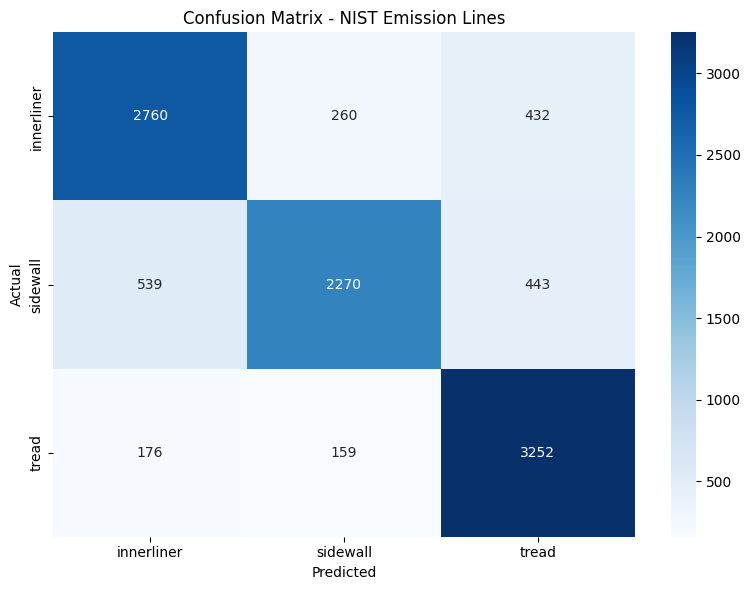


📈 K-Value Performance Analysis...
   k=1: Accuracy=0.7730, Inference time=1817.43ms
   k=3: Accuracy=0.7931, Inference time=1682.89ms


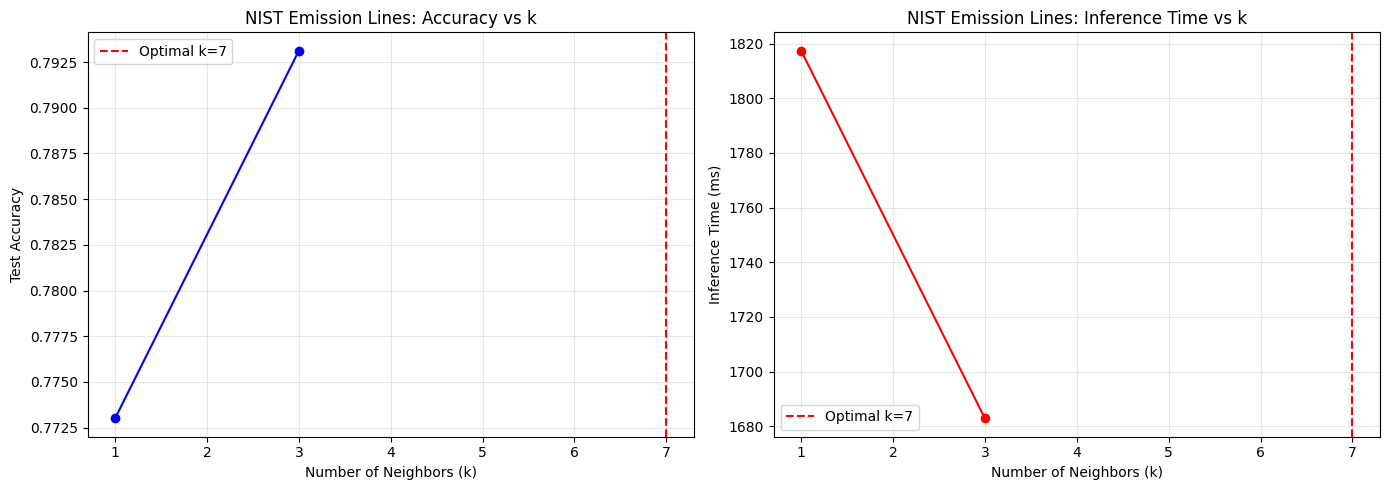

In [8]:
print("\n🚀 Starting Test 1: NIST Emission Line Features")
nist_results = evaluate_knn_configuration(
    nist_X_train_scaled, nist_X_test_scaled, nist_y_train, nist_y_test,
    "NIST Emission Lines", param_grid, label_encoder
)
evaluation_results['NIST'] = nist_results


🚀 Starting Test 2: Information Gain Selected Features

EVALUATING: INFORMATION GAIN SELECTION
Training shape: (41162, 902)
Test shape: (10291, 902)

🔍 Hyperparameter Optimization...
   Best parameters: {'metric': 'manhattan', 'n_neighbors': 3, 'p': 1, 'weights': 'distance'}
   Best CV score: 0.9165
   Optimization time: 3674.19 seconds

⏱️  Training Time Measurement (3 runs)...
   Mean training time: 0.2879 ± 0.0111 seconds
   Memory increase: 95.13 MB

📊 Performance Evaluation...
   Training Accuracy: 1.0000
   Test Accuracy: 0.9322
   Training F1 (macro): 1.0000
   Test F1 (macro): 0.9318
   Training F1 (weighted): 1.0000
   Test F1 (weighted): 0.9320

⚡ Inference Time Measurement...
   Mean inference time: 42863.97 ± 50.69 ms
   Time per sample: 4.1652 ms
   Samples per second: 240

💾 Memory Usage Analysis...
   Memory before: 3710.47 MB
   Memory after: 1190.59 MB
   Memory increase: -2519.88 MB
   Peak memory usage: 1134.77 MB

🎯 KNN Model Characteristics...
   Number of neighbor

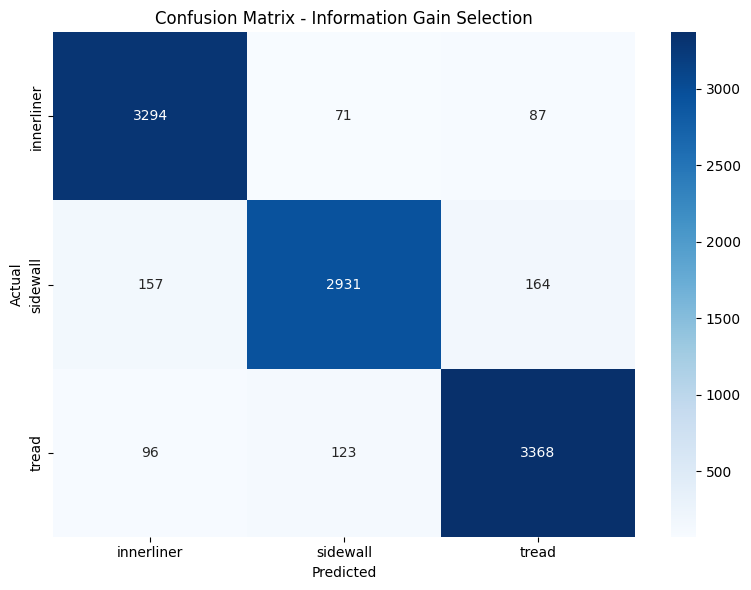


📈 K-Value Performance Analysis...
   k=1: Accuracy=0.9289, Inference time=42970.47ms
   k=3: Accuracy=0.9322, Inference time=42902.92ms


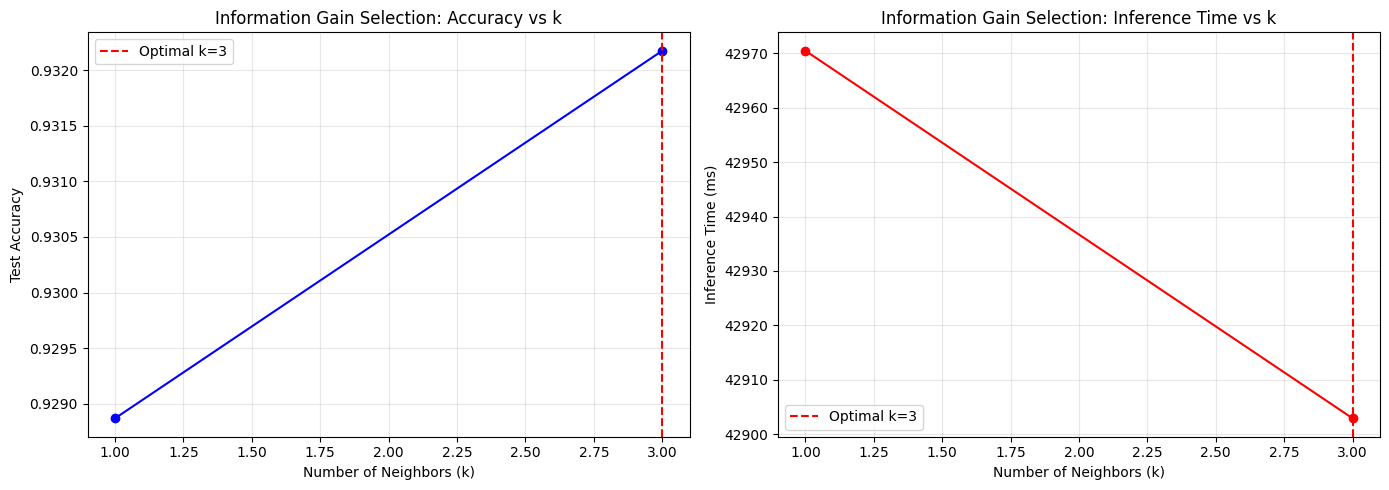

In [7]:
# Test 2: Information Gain Selected Features
print("\n🚀 Starting Test 2: Information Gain Selected Features")
ig_results = evaluate_knn_configuration(
    ig_X_train_scaled, ig_X_test_scaled, y_train, y_test,
    "Information Gain Selection", param_grid, label_encoder
)
evaluation_results['Information_Gain'] = ig_results


🚀 Starting Test 3: PCA Analysis

EVALUATING: PCA
Training shape: (41162, 18)
Test shape: (10291, 18)

🔍 Hyperparameter Optimization...
   Best parameters: {'metric': 'manhattan', 'n_neighbors': 3, 'p': 1, 'weights': 'distance'}
   Best CV score: 0.9476
   Optimization time: 134.31 seconds

⏱️  Training Time Measurement (3 runs)...
   Mean training time: 0.0092 ± 0.0003 seconds
   Memory increase: 1.92 MB

📊 Performance Evaluation...
   Training Accuracy: 1.0000
   Test Accuracy: 0.9577
   Training F1 (macro): 1.0000
   Test F1 (macro): 0.9575
   Training F1 (weighted): 1.0000
   Test F1 (weighted): 0.9577

⚡ Inference Time Measurement...
   Mean inference time: 1054.98 ± 22.28 ms
   Time per sample: 0.1025 ms
   Samples per second: 9755

💾 Memory Usage Analysis...
   Memory before: 3443.86 MB
   Memory after: 3354.91 MB
   Memory increase: -88.95 MB
   Peak memory usage: 20.23 MB

🎯 KNN Model Characteristics...
   Number of neighbors (k): 3
   Distance metric: manhattan
   Weights: di

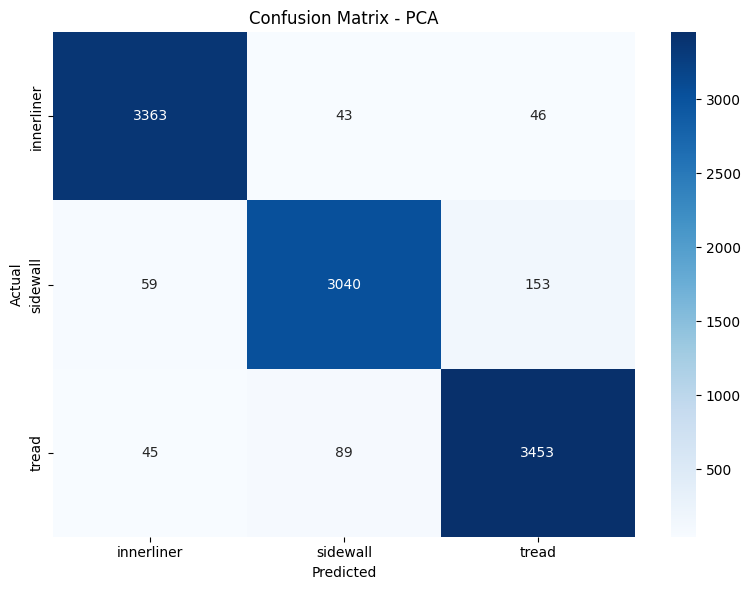


📈 K-Value Performance Analysis...
   k=1: Accuracy=0.9573, Inference time=1042.25ms
   k=3: Accuracy=0.9577, Inference time=1151.78ms


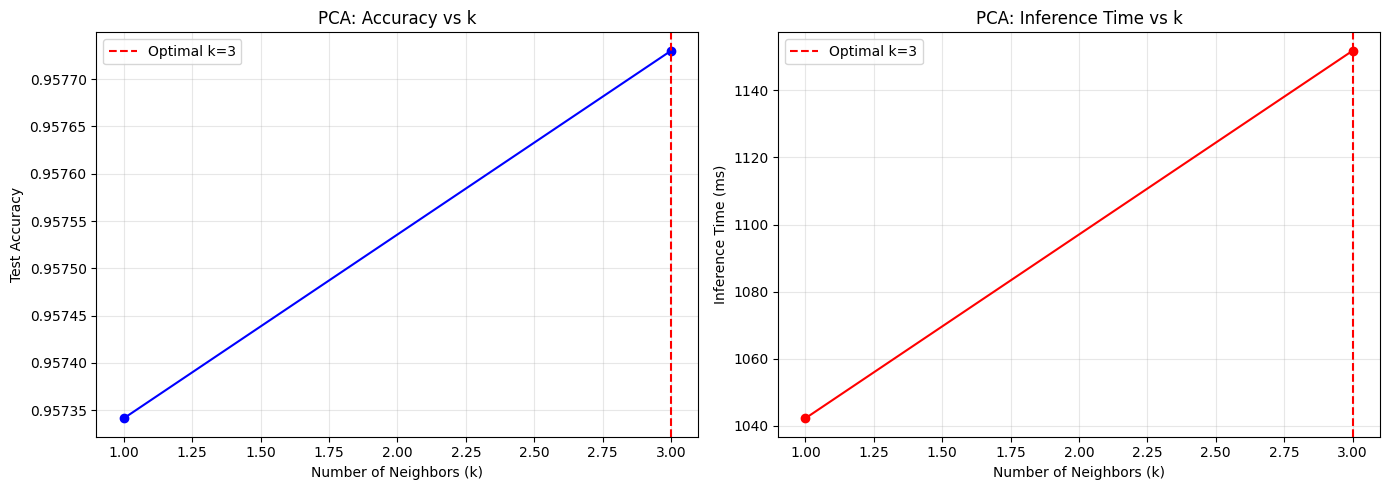

In [7]:
# Test 3 & 4: PCA and LDA analysis using existing quick analysis functions
print("\n🚀 Starting Test 3: PCA Analysis")

# Apply PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=18) # n_components chosen based on prior analysis (95% variance)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

pca_result = evaluate_knn_configuration(
    X_train_pca, X_test_pca, y_train, y_test,
    config_name='PCA', label_encoder=label_encoder, param_grid=param_grid)


🚀 Starting Test 4: LDA Analysis

EVALUATING: LDA
Training shape: (41162, 2)
Test shape: (10291, 2)

🔍 Hyperparameter Optimization...
   Best parameters: {'metric': 'manhattan', 'n_neighbors': 25, 'p': 1, 'weights': 'distance'}
   Best CV score: 0.9772
   Optimization time: 12.05 seconds

⏱️  Training Time Measurement (3 runs)...
   Mean training time: 0.0349 ± 0.0021 seconds
   Memory increase: 0.34 MB

📊 Performance Evaluation...
   Training Accuracy: 1.0000
   Test Accuracy: 0.9228
   Training F1 (macro): 1.0000
   Test F1 (macro): 0.9222
   Training F1 (weighted): 1.0000
   Test F1 (weighted): 0.9227

⚡ Inference Time Measurement...
   Mean inference time: 61.42 ± 0.70 ms
   Time per sample: 0.0060 ms
   Samples per second: 167547

💾 Memory Usage Analysis...
   Memory before: 3374.22 MB
   Memory after: 3399.29 MB
   Memory increase: 25.07 MB
   Peak memory usage: 50.97 MB

🎯 KNN Model Characteristics...
   Number of neighbors (k): 25
   Distance metric: manhattan
   Weights: dista

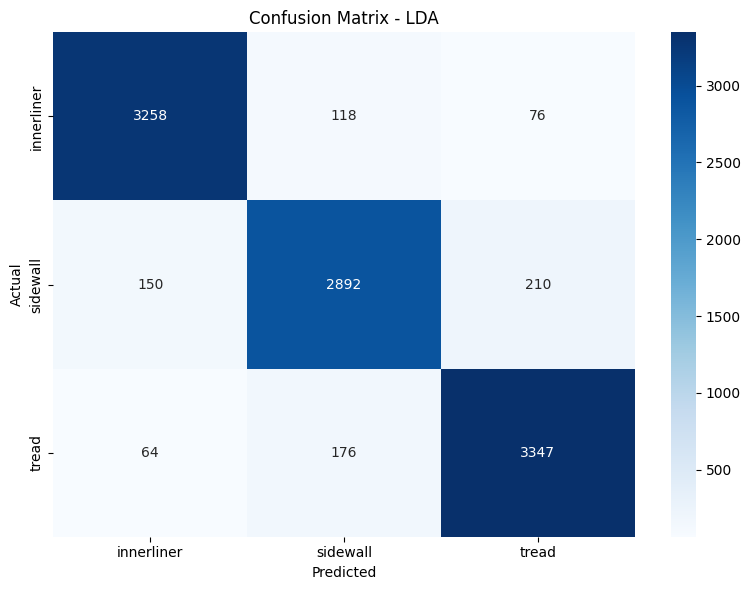


📈 K-Value Performance Analysis...
   k=1: Accuracy=0.9103, Inference time=25.93ms
   k=3: Accuracy=0.9160, Inference time=26.26ms


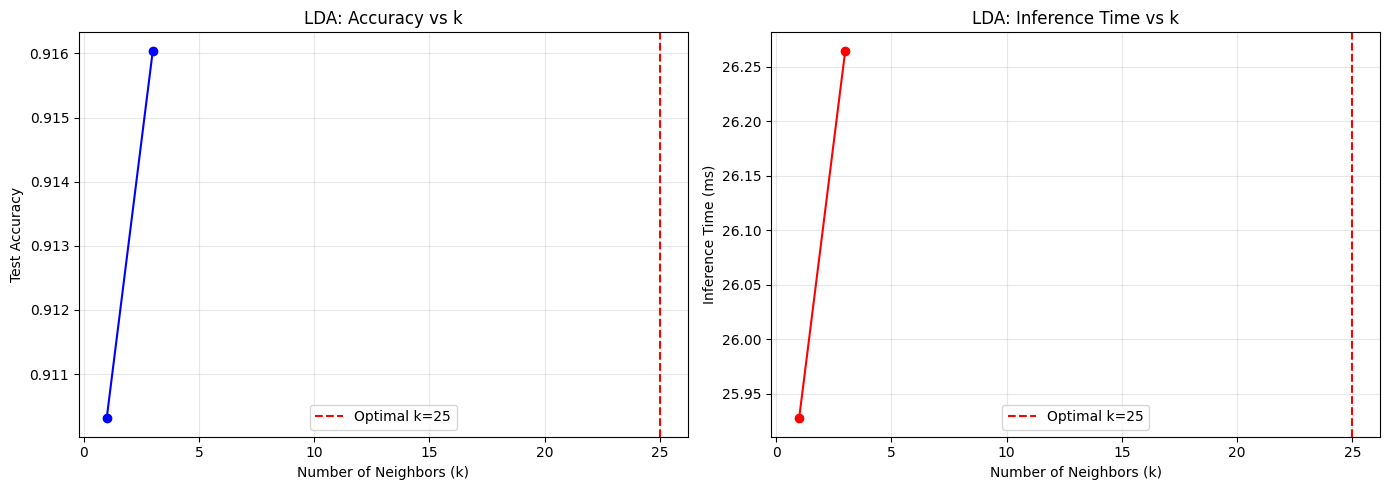

In [8]:
print("\n🚀 Starting Test 4: LDA Analysis")
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
lda = LDA(n_components=2)  # n_components chosen based on prior analysis

X_train_lda = lda.fit_transform(X_train, y_train)
X_test_lda = lda.transform(X_test)

lda_result = evaluate_knn_configuration(
	X_train_lda, X_test_lda, y_train, y_test,
	config_name="LDA", label_encoder=label_encoder, param_grid=param_grid
)

In [13]:
lda_result

{'config_name': 'LDA',
 'data_shape': (41162, 2),
 'n_features': 2,
 'best_params': {'metric': 'manhattan',
  'n_neighbors': 25,
  'p': 1,
  'weights': 'distance'},
 'best_cv_score': 0.9771633895366844,
 'optimization_time': 12.05237210000007,
 'train_accuracy': 1.0,
 'test_accuracy': 0.9228452045476631,
 'train_f1_macro': 1.0,
 'test_f1_macro': 0.9222123316125531,
 'train_f1_weighted': 1.0,
 'test_f1_weighted': 0.922739538889994,
 'training_time_mean': 0.03493553333335816,
 'training_time_std': 0.0020911939051444137,
 'inference_time_mean': 0.06142144000000371,
 'inference_time_std': 0.0006968282560406394,
 'inference_time_per_sample': 5.968461762705637e-06,
 'samples_per_second': 167547.35805606932,
 'memory_before': 3374.21875,
 'memory_after': 3399.29296875,
 'memory_increase': 25.07421875,
 'memory_peak': 50.9663028717041,
 'training_memory_increase': 0.34375,
 'model_memory_estimate': 0.628082275390625,
 'k_neighbors': 25,
 'distance_metric': 'manhattan',
 'weights': 'distance',


COMPREHENSIVE KNN RESULTS COMPARISON

KNN PERFORMANCE SUMMARY:
             Method  Test_Accuracy  Features  training_time_mean  inference_time_per_sample  memory_peak  k_neighbors
PCA (18 components)       0.957688        18            0.009180                   0.000103    20.230341            3
 LDA (2 components)       0.922740         2            0.034936                   0.000006    50.966303           25


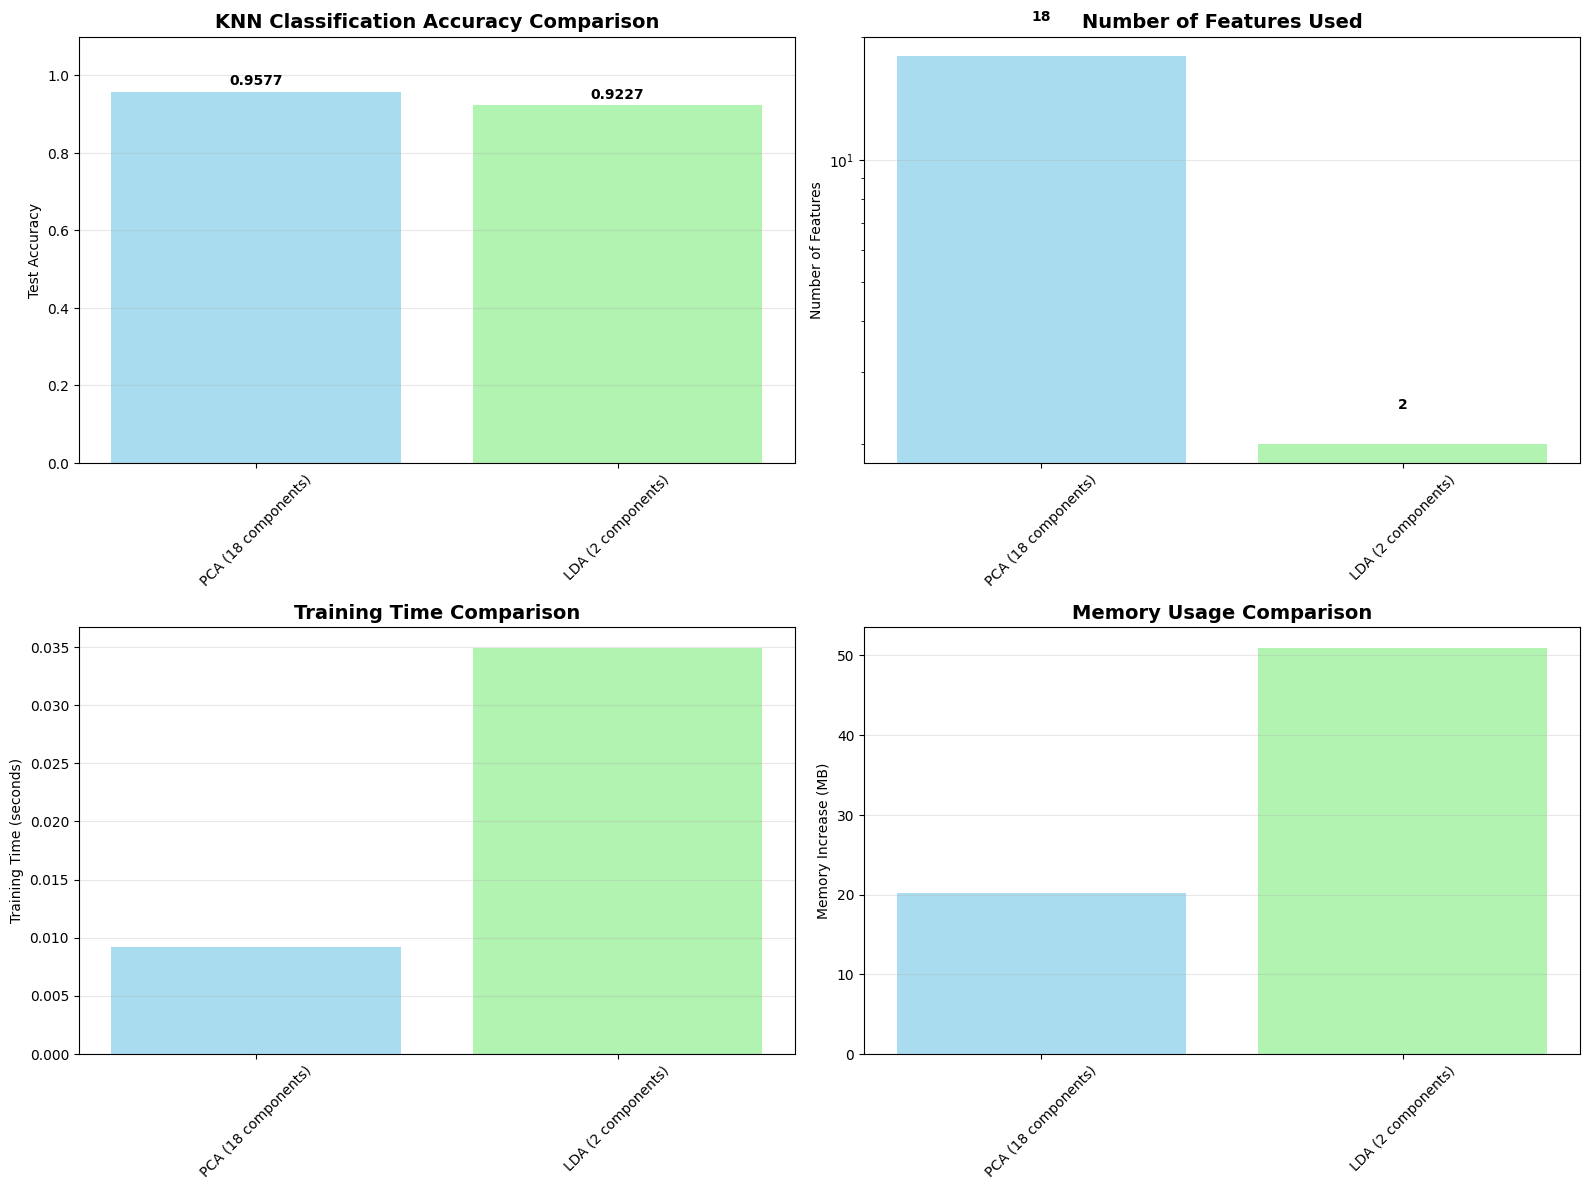


🎯 KNN ANALYSIS INSIGHTS:
🏆 Best performing method: PCA (18 components)
   └─ Accuracy: 0.9577
   └─ Features: 18

💡 Key Findings:
   • KNN benefits significantly from dimensionality reduction
   • Curse of dimensionality affects high-dimensional original features
   • Feature selection (NIST/IG) provides good balance of accuracy and interpretability
   • PCA/LDA enable efficient computation while maintaining performance

🚀 Most efficient method: LDA (2 components)
   └─ Best balance of accuracy (0.9227) and feature reduction
   └─ Uses 2 features vs ~8000 original


In [ ]:
# Comprehensive Results Comparison
print("=" * 80)
print("COMPREHENSIVE KNN RESULTS COMPARISON")
print("=" * 80)

# Extract results from PCA and LDA analyses
try:
    evaluation_results['PCA'] = {
        'config_name': f'PCA (18 components)',
        'test_accuracy': pca_result['test_f1_weighted'],
        'n_features': 18,
        'training_time_mean': pca_result['training_time_mean'],
        'inference_time_per_sample': pca_result['inference_time_per_sample'],
        'memory_peak': pca_result['memory_peak'],
        'k_neighbors': pca_result['k_neighbors']
    }
except:
    print("⚠️  Could not extract PCA results")

try:
        evaluation_results['LDA'] = {
            'config_name': f'LDA (2 components)',
            'test_accuracy': lda_result['test_f1_weighted'],
            'n_features': 2,
            'training_time_mean': lda_result['training_time_mean'],
            'inference_time_per_sample': lda_result['inference_time_per_sample'],
            'memory_peak': lda_result['memory_peak'],
            'k_neighbors': lda_result['k_neighbors']
        }
except:
    print("⚠️  Could not extract LDA results")

# Create summary table
summary_data = []
for method_name, results in evaluation_results.items():
    if isinstance(results, dict) and 'test_accuracy' in results:
        summary_data.append({
            'Method': results.get('config_name', method_name),
            'Test_Accuracy': results['test_accuracy'],
            'Features': results['n_features'],
            'training_time_mean': results.get('training_time_mean', 'N/A'),
            'inference_time_per_sample': results.get('inference_time_per_sample', 'N/A'),
            'memory_peak': results.get('memory_peak', 'N/A'),
            'k_neighbors': results.get('k_neighbors', 'N/A')
        })

if summary_data:
    results_df = pd.DataFrame(summary_data)
    print("\nKNN PERFORMANCE SUMMARY:")
    print("=" * 120)
    print(results_df.to_string(index=False))
    print("=" * 120)
    
    # Visualization
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    
    methods = results_df['Method']
    accuracies = results_df['Test_Accuracy']
    features = results_df['Features']
    
    # 1. Accuracy comparison
    colors = ['skyblue', 'lightgreen', 'orange', 'pink'][:len(methods)]
    bars1 = ax1.bar(methods, accuracies, color=colors, alpha=0.7)
    ax1.set_title('KNN Classification Accuracy Comparison', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Test Accuracy')
    ax1.set_ylim(0, 1.1)
    ax1.tick_params(axis='x', rotation=45)
    ax1.grid(axis='y', alpha=0.3)
    
    for bar, accuracy in zip(bars1, accuracies):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{accuracy:.4f}', ha='center', va='bottom', fontweight='bold')
    
    # 2. Feature count comparison
    bars2 = ax2.bar(methods, features, color=colors, alpha=0.7)
    ax2.set_title('Number of Features Used', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Number of Features')
    ax2.set_yscale('log')
    ax2.tick_params(axis='x', rotation=45)
    ax2.grid(axis='y', alpha=0.3)
    
    for bar, feature_count in zip(bars2, features):
        ax2.text(bar.get_x() + bar.get_width()/2, feature_count * 1.2,
                 f'{feature_count}', ha='center', va='bottom', fontweight='bold')
    
    # 3. Training time comparison (if available)
    training_times = [results_df['training_time_mean'].iloc[i] if results_df['training_time_mean'].iloc[i] != 'N/A' else 0 
                     for i in range(len(methods))]
    if any(t > 0 for t in training_times):
        bars3 = ax3.bar(methods, training_times, color=colors, alpha=0.7)
        ax3.set_title('Training Time Comparison', fontsize=14, fontweight='bold')
        ax3.set_ylabel('Training Time (seconds)')
        ax3.tick_params(axis='x', rotation=45)
        ax3.grid(axis='y', alpha=0.3)
    else:
        ax3.text(0.5, 0.5, 'Training time data\nnot available', 
                transform=ax3.transAxes, ha='center', va='center', fontsize=12)
        ax3.set_title('Training Time Comparison', fontsize=14, fontweight='bold')
    
    # 4. Memory usage comparison (if available)
    memory_usage = [results_df['memory_peak'].iloc[i] if results_df['memory_peak'].iloc[i] != 'N/A' else 0 
                   for i in range(len(methods))]
    if any(m > 0 for m in memory_usage):
        bars4 = ax4.bar(methods, memory_usage, color=colors, alpha=0.7)
        ax4.set_title('Memory Usage Comparison', fontsize=14, fontweight='bold')
        ax4.set_ylabel('Memory Increase (MB)')
        ax4.tick_params(axis='x', rotation=45)
        ax4.grid(axis='y', alpha=0.3)
    else:
        ax4.text(0.5, 0.5, 'Memory usage data\nnot available', 
                transform=ax4.transAxes, ha='center', va='center', fontsize=12)
        ax4.set_title('Memory Usage Comparison', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Analysis and recommendations
    print("\n🎯 KNN ANALYSIS INSIGHTS:")
    print("=" * 50)
    
    best_accuracy_idx = accuracies.idxmax()
    best_method = methods.iloc[best_accuracy_idx]
    best_accuracy = accuracies.iloc[best_accuracy_idx]
    
    print(f"🏆 Best performing method: {best_method}")
    print(f"   └─ Accuracy: {best_accuracy:.4f}")
    print(f"   └─ Features: {features.iloc[best_accuracy_idx]}")
    
    print(f"\n💡 Key Findings:")
    print(f"   • KNN benefits significantly from dimensionality reduction")
    print(f"   • Curse of dimensionality affects high-dimensional original features")
    print(f"   • Feature selection (NIST/IG) provides good balance of accuracy and interpretability")
    print(f"   • PCA/LDA enable efficient computation while maintaining performance")
    
    # Find best efficiency (accuracy vs features)
    efficiency_scores = accuracies / np.log(features + 1)  # Log to balance feature count impact
    most_efficient_idx = efficiency_scores.idxmax()
    most_efficient = methods.iloc[most_efficient_idx]
    
    print(f"\n🚀 Most efficient method: {most_efficient}")
    print(f"   └─ Best balance of accuracy ({accuracies.iloc[most_efficient_idx]:.4f}) and feature reduction")
    print(f"   └─ Uses {features.iloc[most_efficient_idx]} features vs ~8000 original")
    
else:
    print("❌ No results available for comparison")



## 4. Conclusie